In [94]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import legend
from tqdm import tqdm

https://habr.com/ru/articles/486358/

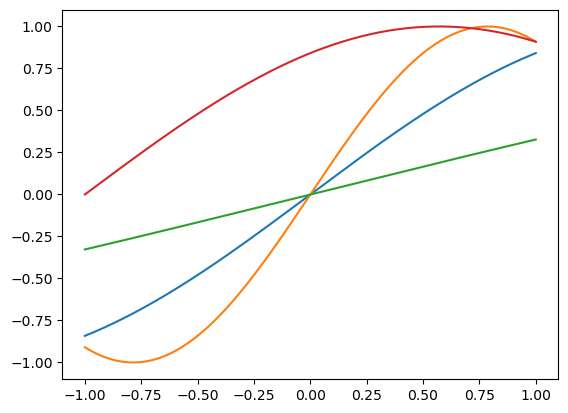

In [95]:
x_axis = np.linspace(-1, 1, 200)
sin1 = np.sin(x_axis)
sin2 = np.sin(2 * x_axis)
sin3 = np.sin(1/3 * x_axis)
sin4 = np.sin(x_axis+1)
sins = [sin1, sin2, sin3, sin4]
for s in sins:
    plt.plot(x_axis, s)

In [96]:
sins = np.array(sins)
sins.shape

(4, 200)

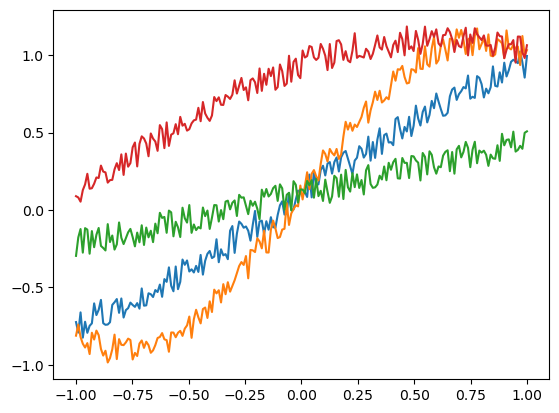

In [97]:
noise = np.random.random(sins.shape)
Y = sins + noise*0.2
for s in Y:
    plt.plot(x_axis, s)

In [24]:
def batch(arr, bs=16, step=1):
    batches = []
    for i in range(0, arr.shape[1]-bs, step):
        batches.append(arr[:,i:i+bs])
    return np.array(batches)
batch(Y).shape

(184, 4, 16)

In [98]:
from torch.nn import Transformer

In [101]:
model = Transformer(
    d_model=4,
    nhead=2,
    num_encoder_layers=1,
    num_decoder_layers=1,
    dim_feedforward = 64
)
model

Transformer(
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0): TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=4, out_features=4, bias=True)
        )
        (linear1): Linear(in_features=4, out_features=64, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=64, out_features=4, bias=True)
        (norm1): LayerNorm((4,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((4,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
    (norm): LayerNorm((4,), eps=1e-05, elementwise_affine=True)
  )
  (decoder): TransformerDecoder(
    (layers): ModuleList(
      (0): TransformerDecoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=4, out_features=4, bias=True)
      

In [102]:
Y_tensor = torch.tensor(batch(Y)).float()
Y_tensor = torch.reshape(Y_tensor, (Y_tensor.shape[0], Y_tensor.shape[2], Y_tensor.shape[1]))
Y_tensor.shape

torch.Size([184, 16, 4])

In [103]:
model(Y_tensor[0], Y_tensor[0]).shape

torch.Size([16, 4])

In [106]:
def train(model, data, epochs=5):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = torch.nn.MSELoss()

    for epoch in range(epochs):
        optimizer.zero_grad()
        epoch_loss = []

        for i in tqdm(range(1, data.shape[0]), desc=f"Epoch {epoch}/{epochs}", leave=True):
            train, true = data[i-1, ...], data[i, ...]
            pred = model(train, train)
            loss = loss_fn(pred, true)
            epoch_loss.append(loss.item())
            loss.backward()
            optimizer.step()

        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}, loss: {sum(epoch_loss)/len(epoch_loss)}")

train(model, Y_tensor, epochs=20)

Epoch 9/20: 100%|██████████| 183/183 [00:00<00:00, 197.24it/s]


Epoch 10, loss: 0.4309477894846859


Epoch 19/20: 100%|██████████| 183/183 [00:01<00:00, 162.41it/s]

Epoch 20, loss: 0.43210919852790936


In [113]:
true = Y_tensor[-1,...].detach().numpy().T
pred = model(Y_tensor[-2,...], Y_tensor[-2,...]).detach().numpy().T
true.shape, pred.shape

((4, 16), (4, 16))

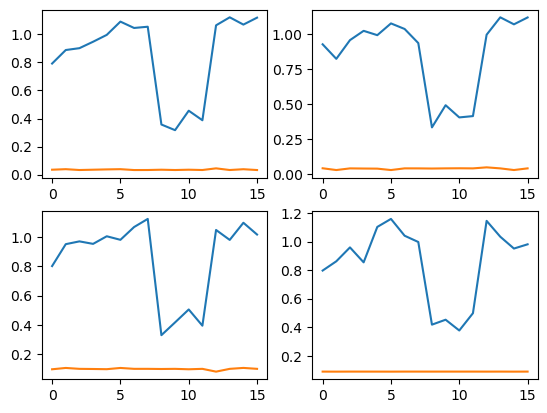

In [116]:
fig, axs = plt.subplots(ncols=2, nrows=2)
for i in range(pred.shape[0]):
    axs[i//2, i%2].plot(true[i, ...])
    axs[i//2, i%2].plot(pred[i, ...])